
# Randomized Gravitational Clustering clásico de Gómez aplicado a *Iris* con **petal length** y **petal width**

## Propósito

Implementación del **Randomized Gravitational Clustering (RGC)** clásico, inspirada en la formulación de Gómez para espacios euclidianos. El análisis se restringe al plano formado por las variables **petal length (cm)** y **petal width (cm)** del conjunto de datos *Iris*.



## 1. Datos y selección de variables

En este cuaderno no se utilizan las cuatro variables originales de *Iris*, sino únicamente las dos variables asociadas al pétalo:

- **petal length (cm)**,
- **petal width (cm)**.

Estas dos características ofrecen una separación visual mucho más clara entre especies que las variables del sépalo y, por tanto, permiten analizar con mayor nitidez la dinámica del RGC clásico en un plano bidimensional.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, adjusted_rand_score

from scipy.cluster.hierarchy import linkage, fcluster, dendrogram

plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.grid"] = True


In [2]:

iris = load_iris(as_frame=True)
selected_features = ["petal length (cm)", "petal width (cm)"]

X_raw = iris.frame[selected_features].to_numpy(dtype=float)
y_true = iris.target.to_numpy()
target_names = iris.target_names

df_iris = iris.frame[selected_features].copy()
df_iris["species"] = [target_names[i] for i in y_true]
df_iris.head()


,petal length (cm),petal width (cm),species
0,1.4,0.2,setosa
1,1.4,0.2,setosa
2,1.3,0.2,setosa
3,1.5,0.2,setosa
4,1.4,0.2,setosa


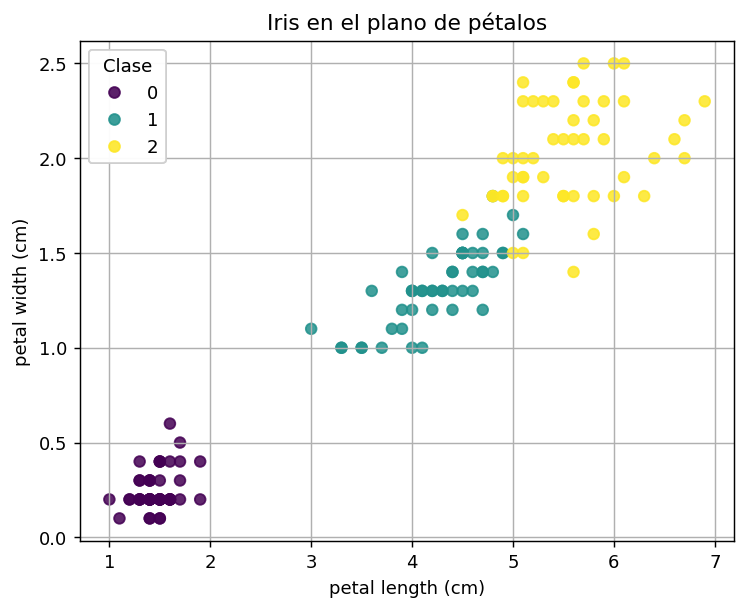

In [3]:

fig, ax = plt.subplots(figsize=(6.5, 5))
scatter = ax.scatter(
    X_raw[:, 0],
    X_raw[:, 1],
    c=y_true,
    s=35,
    alpha=0.85,
)
ax.set_title("Iris en el plano de pétalos")
ax.set_xlabel("petal length (cm)")
ax.set_ylabel("petal width (cm)")
legend = ax.legend(*scatter.legend_elements(), title="Clase")
ax.add_artist(legend)
plt.show()



## 2. Estructuras auxiliares y funciones de evaluación

La implementación gravitacional utiliza una estructura **disjoint-set (union-find)** para representar la fusión virtual de componentes cuando dos puntos quedan a una distancia menor o igual que 
$
\varepsilon
$.

La inercia auxiliar se define como:

$$
\operatorname{Inertia}(k)
=
\sum_{c=1}^{k}
\sum_{x_i \in C_c}
\left\lVert x_i - \mu_c \right\rVert^2,
$$

donde $\mu_c$ es el centroide del clúster $C_c$.


In [4]:

class UnionFind:
    """Disjoint-set con compresión de caminos y unión por rango."""

    def __init__(self, n):
        self.parent = np.arange(n)
        self.rank = np.zeros(n, dtype=int)
        self.size = np.ones(n, dtype=int)

    def find(self, a):
        while self.parent[a] != a:
            self.parent[a] = self.parent[self.parent[a]]
            a = self.parent[a]
        return a

    def union(self, a, b):
        ra, rb = self.find(a), self.find(b)
        if ra == rb:
            return False

        if self.rank[ra] < self.rank[rb]:
            ra, rb = rb, ra

        self.parent[rb] = ra
        self.size[ra] += self.size[rb]

        if self.rank[ra] == self.rank[rb]:
            self.rank[ra] += 1

        return True


def partition_inertia(X, labels):
    X = np.asarray(X)
    labels = np.asarray(labels)

    total = 0.0
    for lab in np.unique(labels):
        if lab == -1:
            continue
        pts = X[labels == lab]
        if len(pts) == 0:
            continue
        centroid = pts.mean(axis=0)
        total += ((pts - centroid) ** 2).sum()
    return float(total)


def summarize_auxiliary_cuts(X_reference, linkage_matrix, y_true=None, max_k=8):
    rows = []
    for k in range(2, max_k + 1):
        labels = fcluster(linkage_matrix, t=k, criterion="maxclust") - 1
        row = {
            "k": int(k),
            "silhouette": float(silhouette_score(X_reference, labels)),
            "inertia": float(partition_inertia(X_reference, labels)),
        }
        if y_true is not None:
            row["ARI"] = float(adjusted_rand_score(y_true, labels))
        rows.append(row)
    return pd.DataFrame(rows)



## 3. Randomized Gravitational Clustering clásico

### 3.1 Idea del algoritmo

En la formulación clásica de Gómez, cada observación se interpreta como una partícula en un espacio euclidiano. Para cada punto \(x_j\), se selecciona aleatoriamente otro punto \(x_k \neq x_j\) y se actualiza el par mediante una ley gravitacional simplificada.

La actualización operativa utilizada aquí es:

$$
\Delta x_{j,k}
=
G \, (x_k - x_j)
\left(\frac{\hat d}{\left\lVert x_k - x_j \right\rVert}\right)^3,
$$

$$
x_j \leftarrow x_j + \Delta x_{j,k},
\qquad
x_k \leftarrow x_k - \Delta x_{j,k}.
$$

Cuando la distancia entre dos puntos cae por debajo de un umbral \(\varepsilon\), sus componentes se unen virtualmente.

El enfriamiento sigue la regla:

$$
G \leftarrow (1-\Delta_G)\,G.
$$

### 3.2 Sobre $\hat d$

En los trabajos de Gómez, \(\hat d\) representa una escala de separación característica utilizada para renormalizar la dinámica con respecto al tamaño del conjunto. En esta implementación operativa del caso euclidiano se usa una aproximación basada en vecinos cercanos:

$$
\hat d
=
\operatorname{mediana}\!\bigl(d_{(k)}(x_i)\bigr),
$$

donde $(d_{(k)}(x_i))$ es la distancia del punto $(x_i)$ a su $(k)$-ésimo vecino más cercano.

### 3.3 Ajuste del caso clásico sobre *Iris*

Primero, se estandariza el plano de pétalos:

$$
z_{ij} = \frac{x_{ij} - \mu_j}{\sigma_j}.
$$

Luego, se ejecuta la dinámica gravitacional clásica sobre estas dos coordenadas estandarizadas.


In [5]:

class ClassicalGomezRGC:
    """Implementación operativa de Randomized Gravitational Clustering clásico."""

    def __init__(
        self,
        G0=0.03,
        cooling=0.02,
        M=120,
        eps_mult=2.0,
        min_cluster_size=3,
        k_hat=5,
        seed=42,
        store_history=False,
    ):
        self.G0 = float(G0)
        self.cooling = float(cooling)
        self.M = int(M)
        self.eps_mult = float(eps_mult)
        self.min_cluster_size = int(min_cluster_size)
        self.k_hat = int(k_hat)
        self.seed = int(seed)
        self.store_history = bool(store_history)

    @staticmethod
    def estimate_d_hat(X, k=5):
        k = min(int(k), len(X) - 1)
        nn = NearestNeighbors(n_neighbors=k + 1)
        nn.fit(X)
        dists, _ = nn.kneighbors(X)
        return float(np.median(dists[:, k]))

    def fit(self, X):
        rng = np.random.default_rng(self.seed)
        X = np.asarray(X, dtype=float)
        n = X.shape[0]

        X_dyn = X.copy()
        uf = UnionFind(n)

        d_hat = self.estimate_d_hat(X_dyn, k=self.k_hat)
        eps = self.eps_mult * d_hat
        G = self.G0

        avg_step = []
        history = [X_dyn.copy()] if self.store_history else None

        for _ in range(self.M):
            step_total = 0.0

            for j in range(n):
                k = rng.integers(0, n - 1)
                if k >= j:
                    k += 1

                delta = X_dyn[k] - X_dyn[j]
                dist = np.linalg.norm(delta) + 1e-12

                step_vec = G * delta * (d_hat / dist) ** 3
                X_dyn[j] += step_vec
                X_dyn[k] -= step_vec
                step_total += np.linalg.norm(step_vec)

                new_dist = np.linalg.norm(X_dyn[k] - X_dyn[j])
                if new_dist <= eps:
                    uf.union(j, k)

            avg_step.append(step_total / n)
            G *= (1.0 - self.cooling)

            if self.store_history:
                history.append(X_dyn.copy())

        roots = np.array([uf.find(i) for i in range(n)])
        uniq, counts = np.unique(roots, return_counts=True)

        labels = -np.ones(n, dtype=int)
        cid = 0
        for root, count in zip(uniq, counts):
            if count >= self.min_cluster_size:
                labels[roots == root] = cid
                cid += 1

        self.labels_ = labels
        self.X_final_ = X_dyn
        self.avg_step_ = np.array(avg_step)
        self.info_ = {
            "d_hat": d_hat,
            "eps": eps,
            "final_G": G,
            "n_clusters": int(len(np.unique(labels[labels >= 0]))),
            "n_noise": int(np.sum(labels == -1)),
        }
        self.history_ = history
        return self


In [6]:

scaler = StandardScaler()
X_std = scaler.fit_transform(X_raw)

classical_model = ClassicalGomezRGC(
    G0=0.03,
    cooling=0.02,
    M=120,
    eps_mult=2.0,
    min_cluster_size=3,
    k_hat=5,
    seed=42,
    store_history=True,
)

classical_model.fit(X_std)
classical_model.info_


{'d_hat': 0.14337895605420936,
 'eps': 0.2867579121084187,
 'final_G': 0.0026561361817787213,
 'n_clusters': 2,
 'n_noise': 4}

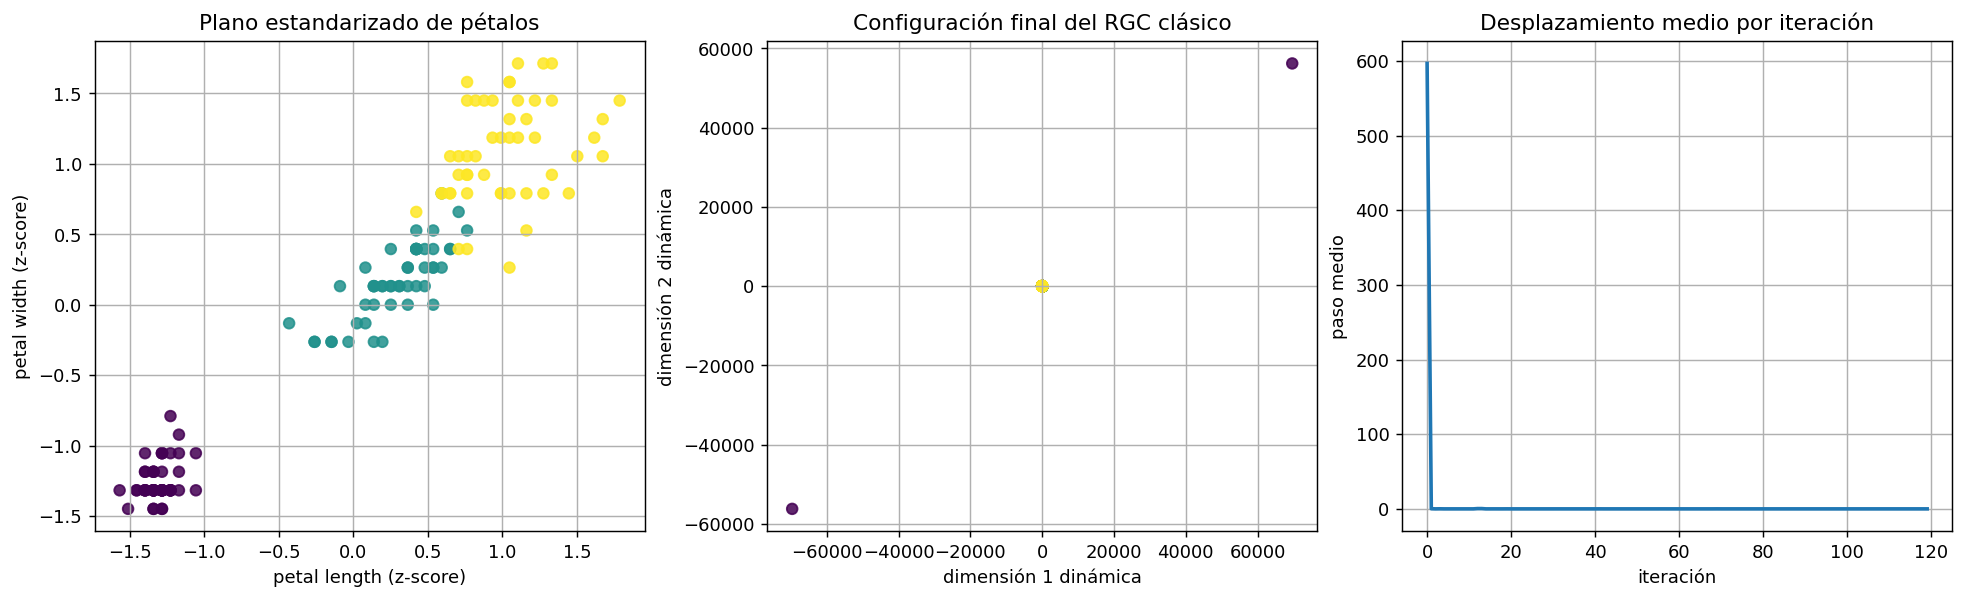

In [7]:

labels_classical = classical_model.labels_
mask_assigned = labels_classical >= 0

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)

axes[0].scatter(X_std[:, 0], X_std[:, 1], c=y_true, s=35, alpha=0.85)
axes[0].set_title("Plano estandarizado de pétalos")
axes[0].set_xlabel("petal length (z-score)")
axes[0].set_ylabel("petal width (z-score)")

axes[1].scatter(
    classical_model.X_final_[:, 0],
    classical_model.X_final_[:, 1],
    c=np.where(labels_classical >= 0, labels_classical, -1),
    s=35,
    alpha=0.85,
)
axes[1].set_title("Configuración final del RGC clásico")
axes[1].set_xlabel("dimensión 1 dinámica")
axes[1].set_ylabel("dimensión 2 dinámica")

axes[2].plot(classical_model.avg_step_, linewidth=2)
axes[2].set_title("Desplazamiento medio por iteración")
axes[2].set_xlabel("iteración")
axes[2].set_ylabel("paso medio")

plt.show()


In [8]:

pd.crosstab(
    pd.Series(y_true, name="Iris real"),
    pd.Series(labels_classical, name="Cluster RGC"),
    dropna=False,
)


Cluster RGC,-1,0,1
Iris real,,,
0,0,50,0
1,4,0,46
2,0,0,50



### 3.4 Lectura del resultado clásico

El RGC clásico produce una configuración final \(X^{(\mathrm{final})}\) y una partición virtual obtenida a partir de las uniones acumuladas durante la dinámica. En esta implementación, los componentes con tamaño menor que un umbral mínimo se conservan como ruido con etiqueta \(-1\).

Como el algoritmo no está diseñado para forzar exactamente \(k=3\), la interpretación del resultado debe hacerse observando simultáneamente:

- la configuración geométrica final,
- la tabla de contingencia respecto a las especies reales,
- la evolución del desplazamiento medio,
- y los diagnósticos auxiliares construidos sobre $(X^{(\mathrm{final})})$.



## 4. Diagnósticos auxiliares para la variante clásica

Sea \(X^{(\mathrm{final})}\) la configuración final producida por la dinámica. Sobre esta configuración se construye una jerarquía auxiliar con criterio de enlace de Ward y se estudian distintos cortes en \(k\).

Este análisis no sustituye al algoritmo gravitacional; únicamente ayuda a inspeccionar la estructura geométrica remanente.


In [9]:

Z_classical = linkage(classical_model.X_final_, method="ward")
summary_classical = summarize_auxiliary_cuts(
    classical_model.X_final_,
    Z_classical,
    y_true=y_true,
    max_k=8,
)
summary_classical


,k,silhouette,inertia,ARI
0,2,0.983268,7.958625e+09,0.000000
1,3,0.986601,1.617760e+04,0.000181
2,4,0.893160,1.140619e+04,0.000200
3,5,0.898657,7.083331e+03,0.000794
4,6,0.898621,4.363889e+03,0.000697
5,7,0.900846,1.829493e+03,0.000601
6,8,0.874946,1.192464e+03,0.000694


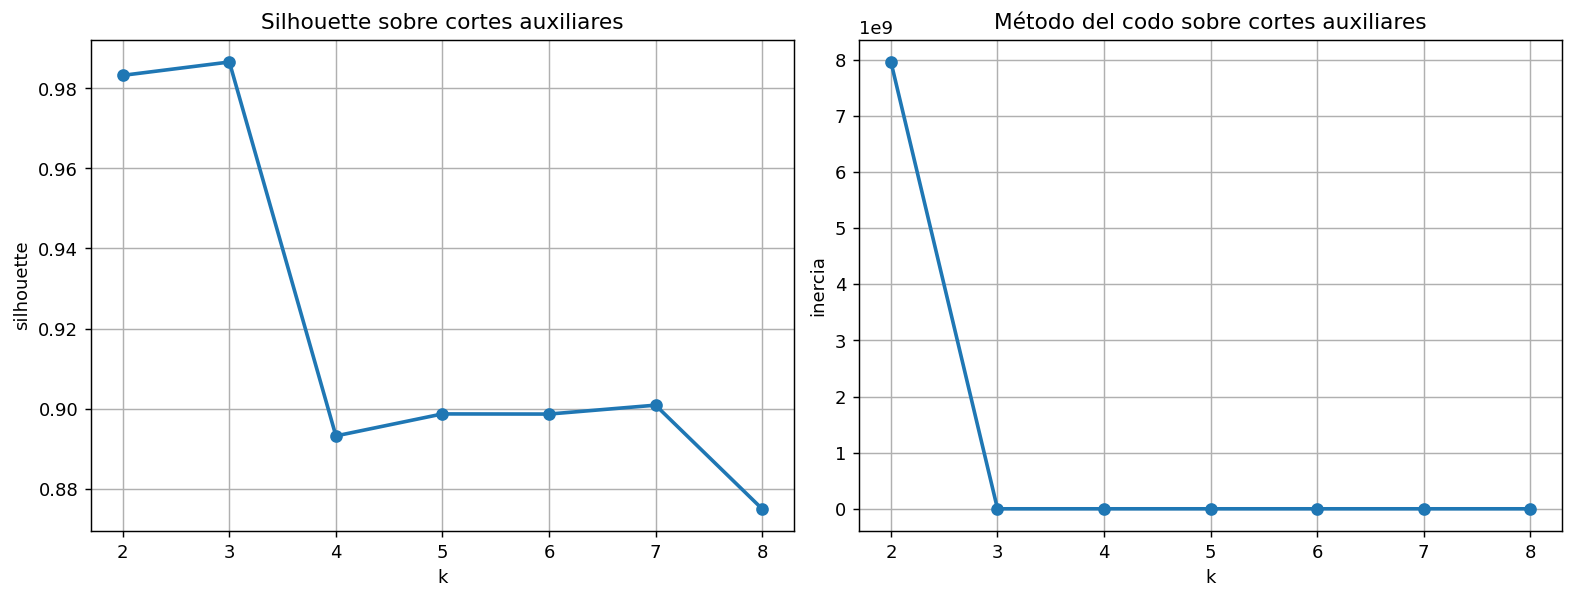

In [10]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)

axes[0].plot(summary_classical["k"], summary_classical["silhouette"], marker="o", linewidth=2)
axes[0].set_title("Silhouette sobre cortes auxiliares")
axes[0].set_xlabel("k")
axes[0].set_ylabel("silhouette")

axes[1].plot(summary_classical["k"], summary_classical["inertia"], marker="o", linewidth=2)
axes[1].set_title("Método del codo sobre cortes auxiliares")
axes[1].set_xlabel("k")
axes[1].set_ylabel("inercia")

plt.show()


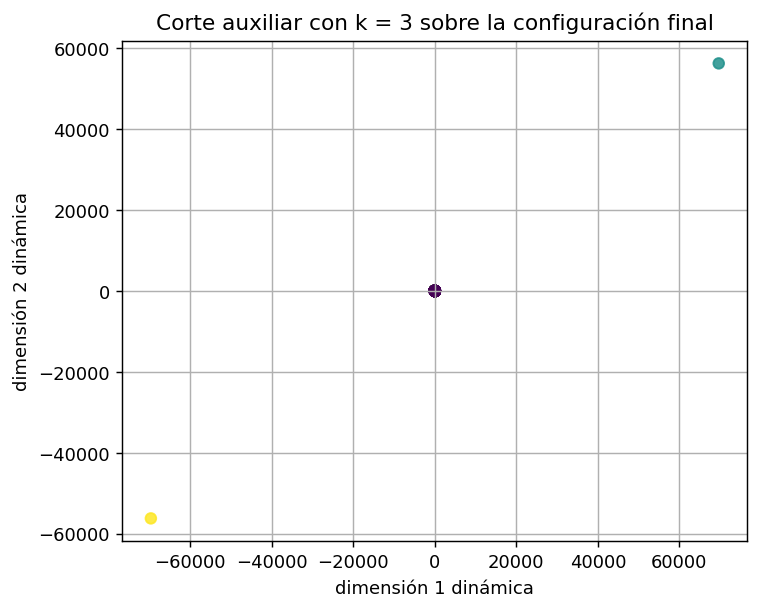

Ward k=3,0,1,2
Iris real,,,
0,50,0,0
1,48,1,1
2,50,0,0


In [12]:

labels_k3 = fcluster(Z_classical, t=3, criterion="maxclust") - 1

fig, ax = plt.subplots(figsize=(6.2, 5))
ax.scatter(
    classical_model.X_final_[:, 0],
    classical_model.X_final_[:, 1],
    c=labels_k3,
    s=35,
    alpha=0.85,
)
ax.set_title("Corte auxiliar con k = 3 sobre la configuración final")
ax.set_xlabel("dimensión 1 dinámica")
ax.set_ylabel("dimensión 2 dinámica")
plt.show()

pd.crosstab(
    pd.Series(y_true, name="Iris real"),
    pd.Series(labels_k3, name="Ward k=3"),
)



## 5. Conclusiones

En el plano formado por **petal length** y **petal width**, el RGC clásico genera una reorganización geométrica útil para revelar estructura de agrupamiento sin imponer directamente un número fijo de clústeres durante la dinámica.

Los diagnósticos auxiliares permiten complementar esa lectura:

- la curva de **silhouette** resume qué cortes jerárquicos preservan mejor la separación geométrica.
- la curva de **inercia** permite inspeccionar visualmente un posible codo.